In [98]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
Data= pd.read_csv('netflix_titles.csv')
df= Data.copy()
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [5]:
df.shape, df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   show_id       8807 non-null   str  
 1   type          8807 non-null   str  
 2   title         8807 non-null   str  
 3   director      6173 non-null   str  
 4   cast          7982 non-null   str  
 5   country       7976 non-null   str  
 6   date_added    8797 non-null   str  
 7   release_year  8807 non-null   int64
 8   rating        8803 non-null   str  
 9   duration      8804 non-null   str  
 10  listed_in     8807 non-null   str  
 11  description   8807 non-null   str  
dtypes: int64(1), str(11)
memory usage: 825.8 KB


((8807, 12), None)

In [9]:
df.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='str')

In [6]:
df.isnull().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

In [10]:
df.drop('show_id', axis= 1, inplace = True)

In [20]:
# Handling missing values
df['director']= df['director'].fillna(df['director'].mode()[0])
df['cast']= df['cast'].fillna(df['cast'].mode()[0])
df['country']= df['country'].fillna(df['country'].mode()[0])
df['date_added']= df['date_added'].fillna(df['date_added'].mode()[0])
df['rating']= df['rating'].fillna(df['rating'].mode()[0])
df['duration']= df['duration'].fillna(df['duration'].mode()[0])

In [21]:
df.isnull().sum()

type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
description     0
dtype: int64

In [24]:
df.duplicated().sum()

np.int64(0)

In [26]:
df.describe()

,release_year
count,8807.000000
mean,2014.180198
std,8.819312
min,1925.000000
25%,2013.000000
50%,2017.000000
75%,2019.000000
max,2021.000000


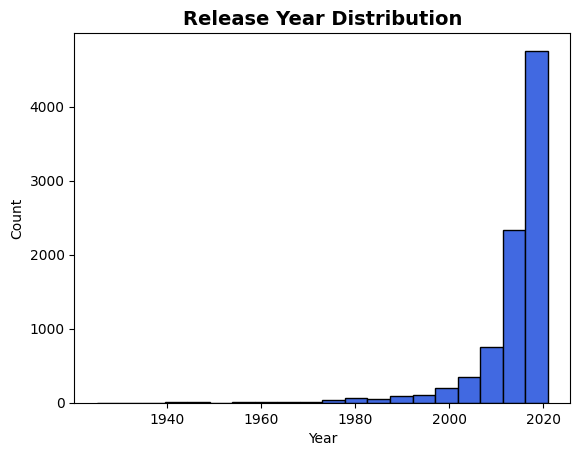

In [ ]:
# check distribution
df['release_year'].hist(bins=20, color='royalblue', edgecolor='black', grid=False)
plt.title("Release Year Distribution", fontsize=14, fontweight='bold')
plt.xlabel("Year")
plt.ylabel("Count")
plt.savefig("images/release_distribution.png")
plt.show()

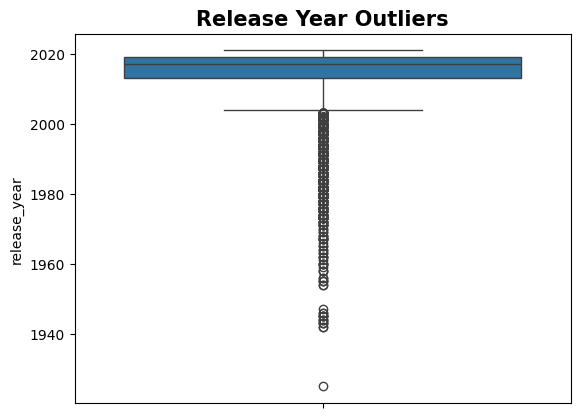

In [102]:
# check outliers
sns.boxplot(df['release_year'])
plt.title("Release Year Outliers", fontsize=15, fontweight='bold')
plt.savefig("images/release_outliers.png")
plt.show()

In [44]:
count= df['type'].value_counts()

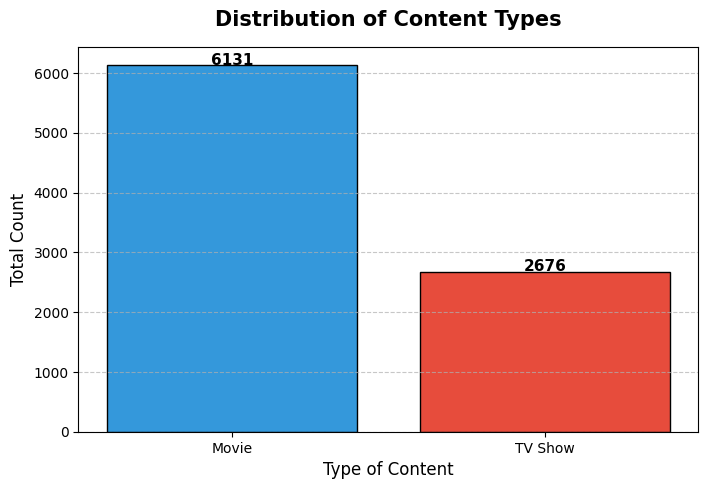

In [ ]:
# distribution of content type
plt.figure(figsize=(8, 5))
plt.bar(count.index, count.values, color=['#3498db', '#e74c3c'], edgecolor='black')
plt.title('Distribution of Content Types', fontsize=15, fontweight='bold', pad=15)
plt.xlabel('Type of Content', fontsize=12)
plt.ylabel('Total Count', fontsize=12)

for i, value in enumerate(count.values):
    plt.text(i, value + 10, str(value), ha='center', fontsize=11, fontweight='bold')

plt.grid(axis='y', linestyle='--', alpha=0.7) 
plt.savefig("images/distribution of content.png")
plt.show()

In [66]:
count= df['country'].value_counts().head(10)

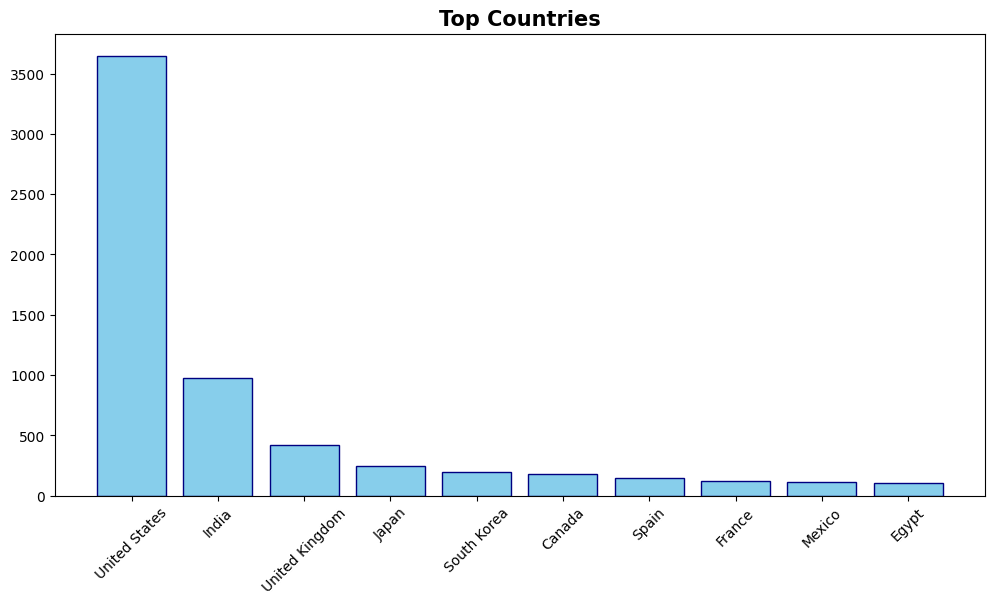

In [87]:
# Top countries
plt.figure(figsize=(12,6))
plt.bar(count.index, count.values, color='skyblue', edgecolor='navy')
plt.title("Top Countries", fontsize=15, fontweight='bold')
plt.xticks(rotation=45)
plt.savefig("images/country_chart.png")
plt.show()

In [82]:
Genres_count= df['listed_in'].value_counts().head(10)

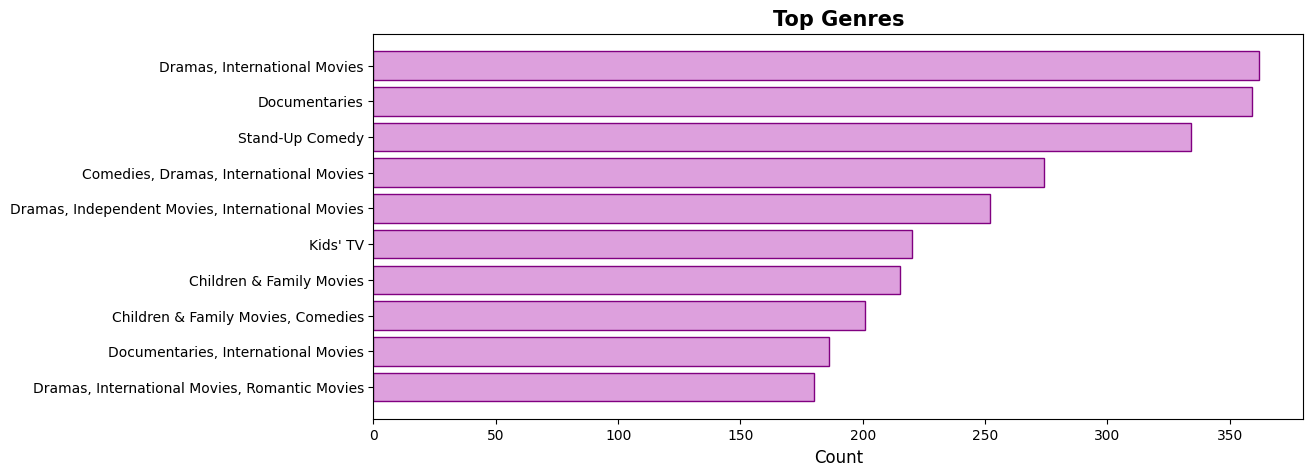

In [ ]:
# top Genres
plt.figure(figsize=(12,5))
plt.barh(Genres_count.index, Genres_count.values, color='plum', edgecolor='purple')
plt.title("Top Genres", fontsize=15, fontweight='bold')
plt.xlabel("Count", fontsize=12)
plt.gca().invert_yaxis() 

plt.savefig("images/genre_chart.png")
plt.show()

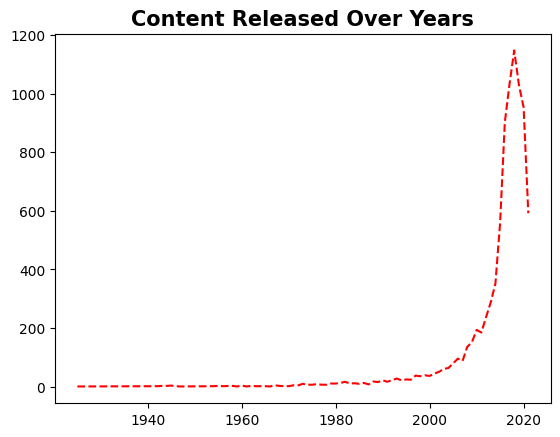

In [ ]:
# year wise trend
count= df['release_year'].value_counts().sort_index()
plt.plot(count.index, count.values, ls= 'dashed', c= 'red')
plt.title("Content Released Over Years", fontsize=15, fontweight='bold')
plt.savefig("images/year_trend.png")
plt.show()


Insights:
- Movies are more common than TV Shows
- USA produces most Netflix content
- Content increased after 2015
- Drama and Comedy are most popular genres

ValueError: could not convert string to float: 'Movie'

<Figure size 1200x600 with 0 Axes>